In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import copy
from datetime import datetime, timedelta
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import brier_score_loss
from sklearn.metrics import make_scorer
from sklearn.utils.class_weight import compute_class_weight
import sys
import os
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
import glob 


from sklearn import datasets, ensemble
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.utils import class_weight
import json

import xgboost as xgb
from bayes_opt import BayesianOptimization
import shap
import string

/glade/work/jhayron/conda-envs/pytorch_wr/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
def generate_random_forecast(df_week_0, seed_value=42):
    # Set the random seed for reproducibility
    np.random.seed(seed_value)
    
    # Step 1: Get unique classes and their frequencies
    values = df_week_0[df_week_0.keys()[0]].value_counts()
    
    # Step 2: Calculate the probabilities for each class
    classes = values.index  # Unique classes
    probabilities = values / values.sum()  # Normalize to get probability distribution
    
    # Step 3: Generate a random forecast based on the probabilities
    random_forecast = np.random.choice(classes, size=len(df_week_0), p=probabilities)
    
    # Step 4: Return the random forecast as a DataFrame or Series
    forecast_df = pd.DataFrame(random_forecast, index=df_week_0.index, columns=['y_predicted'])
    
    return forecast_df

def generate_random_forecast_probabilities(df_week_0, seed_value=42):
    # Set the random seed for reproducibility
    np.random.seed(seed_value)
    # Step 1: Get unique classes and their frequencies
    values = df_week_0[df_week_0.keys()[0]].value_counts()
    
    # Step 2: Calculate the probabilities for each class
    classes = values.index  # Unique classes
    probabilities = values / values.sum()  # Normalize to get probability distribution
    
    # Step 3: Create a probability forecast for each sample
    # Create a 2D array where each row is the same probability distribution
    prob_matrix = np.tile(probabilities.values, (len(df_week_0), 1))
    
    # Step 4: Return the probability matrix as a DataFrame
    forecast_df = pd.DataFrame(prob_matrix, index=df_week_0.index, columns=classes)[np.arange(len(classes))]
    
    return forecast_df

def generate_random_forecast_with_monthly_probabilities(df_week_0, seed_value=42):
    # Set the random seed for reproducibility
    np.random.seed(seed_value)
    
    # Extract the month from the index (assuming the index is a datetime index)
    df_week_0['month'] = df_week_0.index.month
    
    # Prepare an empty list to store the random forecast
    forecasts = []
    
    # Loop through each month
    for month in range(1, 13):  # Loop through months 1 to 12
        # Filter data for the current month
        month_data = df_week_0[df_week_0['month'] == month]
        
        # Step 1: Get unique classes and their frequencies for the current month
        values = month_data[df_week_0.keys()[0]].value_counts()
        
        # Step 2: Calculate the probabilities for each class in the current month
        classes = values.index  # Unique classes
        probabilities = values / values.sum()  # Normalize to get probability distribution
        
        # Step 3: Generate random forecasts for the current month based on the probabilities
        month_forecast = np.random.choice(classes, size=len(month_data), p=probabilities)
        
        # Store the forecast for the current month
        forecasts.append(pd.Series(month_forecast, index=month_data.index))
    
    # Combine all monthly forecasts into one DataFrame
    forecast_df = pd.concat(forecasts)
    forecast_df = forecast_df.sort_index()  # Sort the index to preserve the original order
    forecast_df = pd.DataFrame(forecast_df,columns=['y_predicted'])
    return forecast_df
    
def generate_probability_forecast_with_monthly_probabilities(df_week_0, seed_value=42):
    # Set the random seed for reproducibility
    np.random.seed(seed_value)
    
    # Extract the month from the index (assuming the index is a datetime index)
    df_week_0['month'] = df_week_0.index.month
    
    # Prepare an empty DataFrame to store the probability forecasts
    all_probabilities = pd.DataFrame(index=df_week_0.index)
    
    # Loop through each month
    for month in range(1, 13):  # Loop through months 1 to 12
        # Filter data for the current month
        month_data = df_week_0[df_week_0['month'] == month]
        
        if month_data.empty:
            continue  # Skip if there's no data for the month
        
        # Step 1: Get unique classes and their frequencies for the current month
        values = month_data[df_week_0.keys()[0]].value_counts()
        
        # Step 2: Calculate the probabilities for each class in the current month
        classes = values.index  # Unique classes
        probabilities = values / values.sum()  # Normalize to get probability distribution
        
        # Step 3: Create a probability matrix for the current month
        prob_matrix = np.tile(probabilities.values, (len(month_data), 1))
        
        # Create a DataFrame for this month's probabilities with appropriate columns
        month_prob_df = pd.DataFrame(prob_matrix, index=month_data.index, columns=classes)
        
        # Append this month's DataFrame to the overall probability DataFrame
        all_probabilities = pd.concat([all_probabilities, month_prob_df])
    
    # Sort the index to match the original order
    all_probabilities = all_probabilities.sort_index()
    
    # Fill missing columns with zeros for months that do not include certain classes
    all_classes = df_week_0[df_week_0.keys()[0]].unique()
    all_probabilities = all_probabilities.reindex(columns=all_classes, fill_value=0).dropna()[np.arange(len(classes))]
    
    return all_probabilities

In [7]:
wr_original_series = pd.read_csv('/glade/work/jhayron/Data4Predictability/WR_Series_v20241226.csv',\
                index_col=0,names=['week0','dist'],skiprows=1,parse_dates=True)
# Rolling window for mode
rolling_mode = (
    wr_original_series.rolling('7d', center=True,min_periods=7)
    .apply(lambda x: x.mode()[0] if not x.mode().empty else float('nan'))
).shift(-3)

# Rolling window for the count of the mode
rolling_mode_count = (
    wr_original_series.rolling('7d', center=True,min_periods=7)
    .apply(lambda x: (x == x.mode()[0]).sum() if not x.mode().empty else 0)
).shift(-3)

# If duration of WR during week was less than 4, assing NO WR class
rolling_mode.loc[rolling_mode_count['week0']<4,'week0'] = 4
wr_series_mode = copy.deepcopy(rolling_mode)
time_index = pd.to_datetime(wr_series_mode.index).dayofweek
wr_series_mode = wr_series_mode.iloc[time_index.isin([0,3])].dropna()
wr_series = copy.deepcopy(wr_series_mode)

for wk in range(2,10):
    series_temp = copy.deepcopy(wr_series["week0"])
    series_temp.index = series_temp.index - timedelta(weeks = wk-1)
    series_temp.name = f'week{wk-1}'
    if wk==2:
        df_shifts = pd.concat([pd.DataFrame(wr_series["week0"]),pd.DataFrame(series_temp)],axis=1)  
    else:
        df_shifts = pd.concat([df_shifts,pd.DataFrame(series_temp)],axis=1)

In [8]:
list_files_anoms = np.sort(glob.glob('/glade/derecho/scratch/jhayron/Data4Predictability/WeeklyAnoms_DetrendedStd_v3_2dg/*.nc'))
list_vars = [list_files_anoms[i].split('/')[-1][:-3] for i in range(len(list_files_anoms))]

for ivar,var in enumerate(list_vars):
    print(ivar,var)

0 IC_SODA
1 IT_SODA
2 MLD_SODA
3 OHC100_SODA
4 OHC200_SODA
5 OHC300_SODA
6 OHC50_SODA
7 OHC700_SODA
8 OLR_ERA5
9 SD_ERA5
10 SSH_SODA
11 SST_OISSTv2
12 SST_SODA
13 STL_1m_ERA5
14 STL_28cm_ERA5
15 STL_7cm_ERA5
16 STL_full_ERA5
17 SWVL_1m_ERA5
18 SWVL_28cm_ERA5
19 SWVL_7cm_ERA5
20 SWVL_full_ERA5
21 U10_ERA5
22 U200_ERA5
23 Z500_ERA5


In [9]:
indices_vars_atm = [8,21,22,23]
indices_vars_ocn = [0,1,2,3,4,5,6,7,10,11,12]
indices_vars_lnd = [9,13,14,15,16,17,18,19,20]

# indices_vars_atm = [8,21]
# indices_vars_ocn = [0,1,2,3,4,6,7,12]
# indices_vars_lnd = [13,14,15,16,18,19,20]

In [10]:
all_indices  = np.concatenate([indices_vars_atm,indices_vars_ocn,indices_vars_lnd])

In [11]:
path_results = '/glade/derecho/scratch/jhayron/Data4Predictability/ResultsXGBoost/Results_v20241226/'

# Z500 week 4

In [12]:
def compute_f1_and_range(results_temp):
    metric_iterations = []
    for _ in range(100):  # Adjust the number of iterations as needed
        sample_indices = np.random.choice(results_temp.index, size=int(len(results_temp)), replace=True)
        sampled_data = results_temp.loc[sample_indices]
        metric_iterations.append(f1_score(sampled_data['y_true'], 
                                            sampled_data['y_predicted'],average='micro'))
    # accuracy_mean = np.mean(accuracy_iterations)
    metric_mean = f1_score(results_temp['y_true'],results_temp['y_predicted'],average='micro')
    metric_95th = np.percentile(metric_iterations,95)
    metric_5th = np.percentile(metric_iterations,5)
    return metric_mean, metric_95th, metric_5th

In [207]:
ivar=4
week_out=3

In [208]:
results_weeks = {}
results_probs_weeks = {}

for week_out in range(1,9):
    print(f'WEEK: {week_out}')
    week_out_str = f'week{week_out}'
    df_results_full = pd.read_csv(f'{path_results}Results_{list_vars[ivar]}_{week_out_str}.csv',
                                 index_col=0, parse_dates=True)
    results_weeks[week_out_str] = df_results_full
    print(np.bincount(results_weeks[week_out_str]['y_true'])/len(results_weeks[week_out_str]))
    print(np.bincount(results_weeks[week_out_str]['y_predicted'])/len(results_weeks[week_out_str]))

WEEK: 1
[0.23535062 0.20509126 0.1623439  0.11959654 0.27761768]
[0.24255524 0.21685879 0.10902978 0.0549952  0.376561  ]
WEEK: 2
[0.23487032 0.20509126 0.1623439  0.11959654 0.27809798]
[0.20557157 0.20317003 0.11551393 0.0326609  0.44308357]
WEEK: 3
[0.23439001 0.20557157 0.1623439  0.11959654 0.27809798]
[0.22142171 0.21469741 0.11239193 0.06147935 0.39000961]
WEEK: 4
[0.23439001 0.20557157 0.1623439  0.11959654 0.27809798]
[0.25072046 0.17915466 0.06436119 0.05067243 0.45509126]
WEEK: 5
[0.23450264 0.20567035 0.16242191 0.11941374 0.27799135]
[0.25492552 0.19990389 0.08841903 0.10307544 0.35367612]
WEEK: 6
[0.234375   0.20576923 0.1625     0.11923077 0.278125  ]
[0.33942308 0.178125   0.05769231 0.04495192 0.37980769]
WEEK: 7
[0.23424723 0.20586821 0.16257816 0.11928812 0.27801828]
[0.25300625 0.20514671 0.11159211 0.07479557 0.35545936]
WEEK: 8
[0.23435996 0.20596728 0.16241578 0.11934552 0.27791145]
[0.28128008 0.2033205  0.09504331 0.09528393 0.32507218]


In [209]:
week_out_str = f'week{week_out}'
df_week_forecast = df_shifts[[week_out_str]].dropna()
random_forecast = generate_random_forecast(df_week_forecast, seed_value=42)    
climatology_forecast = generate_random_forecast_with_monthly_probabilities(df_week_forecast, seed_value=42)

df_results_temp = results_weeks[week_out_str]

df_results_temp_persistence = copy.deepcopy(df_results_temp)
df_week_0 = df_shifts[['week0']].dropna()
df_results_temp_persistence['y_predicted'] = df_week_0.loc[df_results_temp['y_true'].index].values

df_results_temp_random = copy.deepcopy(df_results_temp)
df_results_temp_random['y_predicted'] = random_forecast.loc[df_results_temp['y_true'].index].values

df_results_temp_clima = copy.deepcopy(df_results_temp)
df_results_temp_clima['y_predicted'] = climatology_forecast.loc[df_results_temp['y_true'].index].values

f1_xgb = compute_f1_and_range(df_results_temp)
f1_persistence = compute_f1_and_range(df_results_temp_persistence)
f1_climatology = compute_f1_and_range(df_results_temp_clima)
f1_random = compute_f1_and_range(df_results_temp_random)

# Just class no WR

In [210]:
def compute_accuracy_and_range(results_temp):
    metric_iterations = []
    for _ in range(100):  # Adjust the number of iterations as needed
        sample_indices = np.random.choice(results_temp.index, size=int(len(results_temp)), replace=True)
        sampled_data = results_temp.loc[sample_indices]
        metric_iterations.append(accuracy_score(sampled_data['y_true'], 
                                            sampled_data['y_predicted']))
    # accuracy_mean = np.mean(accuracy_iterations)
    metric_mean = accuracy_score(results_temp['y_true'],results_temp['y_predicted'])
    metric_95th = np.percentile(metric_iterations,95)
    metric_5th = np.percentile(metric_iterations,5)
    return metric_mean, metric_95th, metric_5th

In [211]:
weather_regime=4
season='Winter'
indices_seasons = {'Winter':[12,1,2],
                   'Spring':[3,4,5],
                   'Summer':[6,7,8],
                   'Fall':[9,10,11]}

In [212]:
results_weeks = {}
results_probs_weeks = {}

for week_out in [week_out]:
    # print(f'WEEK: {week_out}')
    week_out_str = f'week{week_out}'
    df_results_full = pd.read_csv(f'{path_results}Results_{list_vars[ivar]}_{week_out_str}.csv',
                                 index_col=0, parse_dates=True)
    #### Filter by wr ####
    df_results_full = df_results_full.loc[(df_results_full['y_true']==weather_regime)\
        |(df_results_full['y_predicted']==weather_regime)]
    #### Filter by season ####
    df_results_full = df_results_full.loc[(df_results_full.index.month==indices_seasons[season][0])|\
                    (df_results_full.index.month==indices_seasons[season][1])|\
                    (df_results_full.index.month==indices_seasons[season][2])]
    ##########################
    results_weeks[week_out_str] = df_results_full

In [213]:
df_results_full = pd.read_csv(f'{path_results}Results_{list_vars[ivar]}_{week_out_str}.csv',
                                 index_col=0, parse_dates=True)
df_results_full = df_results_full.loc[(df_results_full.index.month==indices_seasons[season][0])|\
                (df_results_full.index.month==indices_seasons[season][1])|\
                (df_results_full.index.month==indices_seasons[season][2])]

freq_winter_pred = np.bincount(df_results_full['y_predicted'])/np.sum(np.bincount(df_results_full['y_predicted']))
freq_winter_true = np.bincount(df_results_full['y_true'])/np.sum(np.bincount(df_results_full['y_true']))

In [214]:
weather_regime=4
season='Summer'
indices_seasons = {'Winter':[12,1,2],
                   'Spring':[3,4,5],
                   'Summer':[6,7,8],
                   'Fall':[9,10,11]}

In [215]:
results_weeks = {}
results_probs_weeks = {}

for week_out in [week_out]:
    # print(f'WEEK: {week_out}')
    week_out_str = f'week{week_out}'
    df_results_full = pd.read_csv(f'{path_results}Results_{list_vars[ivar]}_{week_out_str}.csv',
                                 index_col=0, parse_dates=True)
    #### Filter by wr ####
    df_results_full = df_results_full.loc[(df_results_full['y_true']==weather_regime)\
        |(df_results_full['y_predicted']==weather_regime)]
    #### Filter by season ####
    df_results_full = df_results_full.loc[(df_results_full.index.month==indices_seasons[season][0])|\
                    (df_results_full.index.month==indices_seasons[season][1])|\
                    (df_results_full.index.month==indices_seasons[season][2])]
    ##########################
    results_weeks[week_out_str] = df_results_full

In [216]:
df_results_full = pd.read_csv(f'{path_results}Results_{list_vars[ivar]}_{week_out_str}.csv',
                                 index_col=0, parse_dates=True)
df_results_full = df_results_full.loc[(df_results_full.index.month==indices_seasons[season][0])|\
                (df_results_full.index.month==indices_seasons[season][1])|\
                (df_results_full.index.month==indices_seasons[season][2])]

freq_summer_pred = np.bincount(df_results_full['y_predicted'])/np.sum(np.bincount(df_results_full['y_predicted']))
freq_summer_true = np.bincount(df_results_full['y_true'])/np.sum(np.bincount(df_results_full['y_true']))

In [217]:
names_wrs = ['PT','PR','GH','AR','No WR']

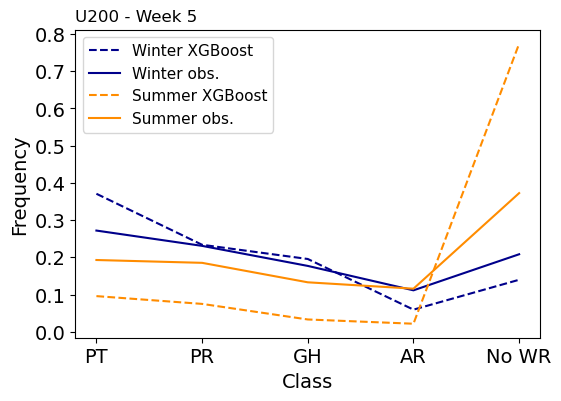

In [206]:
plt.figure(figsize=(6,4))
plt.plot(freq_winter_pred,color='darkblue',ls='dashed',label='Winter XGBoost')
plt.plot(freq_winter_true,color='darkblue',label='Winter obs.')

plt.plot(freq_summer_pred,color='darkorange',ls='dashed',label='Summer XGBoost')
plt.plot(freq_summer_true,color='darkorange',label='Summer obs.')

plt.legend(fontsize=11)
plt.xticks(np.arange(0,5),names_wrs,fontsize=14)
plt.yticks(fontsize=14)
plt.ylabel('Frequency',fontsize=14)
plt.xlabel('Class',fontsize=14)
plt.title('U200 - Week 5',loc='left')
plt.savefig('SupFreqs_U200_wk5.png',bbox_inches='tight')

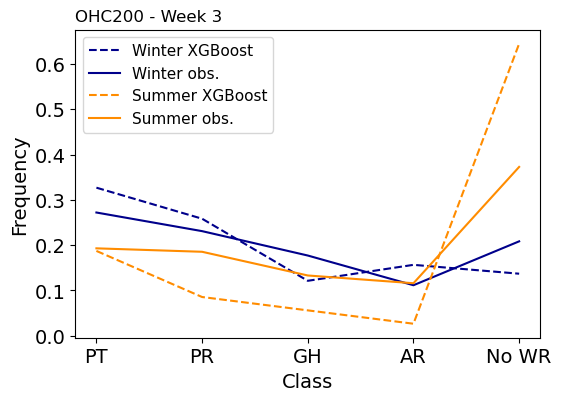

In [218]:
plt.figure(figsize=(6,4))
plt.plot(freq_winter_pred,color='darkblue',ls='dashed',label='Winter XGBoost')
plt.plot(freq_winter_true,color='darkblue',label='Winter obs.')

plt.plot(freq_summer_pred,color='darkorange',ls='dashed',label='Summer XGBoost')
plt.plot(freq_summer_true,color='darkorange',label='Summer obs.')

plt.legend(fontsize=11)
plt.xticks(np.arange(0,5),names_wrs,fontsize=14)
plt.yticks(fontsize=14)
plt.ylabel('Frequency',fontsize=14)
plt.xlabel('Class',fontsize=14)
plt.title('OHC200 - Week 3',loc='left')
plt.savefig('SupFreqs_OHC200_wk3.png',bbox_inches='tight')

# all vars

In [219]:
freqs_forecast_winter = []
for ivar in range(0,24):
    weather_regime=4
    season='Winter'
    indices_seasons = {'Winter':[12,1,2],
                       'Spring':[3,4,5],
                       'Summer':[6,7,8],
                       'Fall':[9,10,11]}
    
    results_weeks = {}
    results_probs_weeks = {}
    
    for week_out in [week_out]:
        # print(f'WEEK: {week_out}')
        week_out_str = f'week{week_out}'
        df_results_full = pd.read_csv(f'{path_results}Results_{list_vars[ivar]}_{week_out_str}.csv',
                                     index_col=0, parse_dates=True)
        #### Filter by wr ####
        df_results_full = df_results_full.loc[(df_results_full['y_true']==weather_regime)\
            |(df_results_full['y_predicted']==weather_regime)]
        #### Filter by season ####
        df_results_full = df_results_full.loc[(df_results_full.index.month==indices_seasons[season][0])|\
                        (df_results_full.index.month==indices_seasons[season][1])|\
                        (df_results_full.index.month==indices_seasons[season][2])]
        ##########################
        results_weeks[week_out_str] = df_results_full
    
    df_results_full = pd.read_csv(f'{path_results}Results_{list_vars[ivar]}_{week_out_str}.csv',
                                     index_col=0, parse_dates=True)
    df_results_full = df_results_full.loc[(df_results_full.index.month==indices_seasons[season][0])|\
                    (df_results_full.index.month==indices_seasons[season][1])|\
                    (df_results_full.index.month==indices_seasons[season][2])]
    
    freq_winter_pred = np.bincount(df_results_full['y_predicted'])/np.sum(np.bincount(df_results_full['y_predicted']))
    freq_winter_true = np.bincount(df_results_full['y_true'])/np.sum(np.bincount(df_results_full['y_true']))

    freqs_forecast_winter.append(freq_winter_pred)

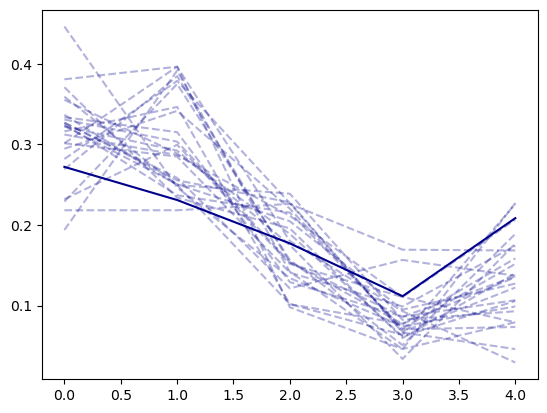

In [226]:
for ivar in range(0,24):
    plt.plot(freqs_forecast_winter[ivar],color='darkblue',ls='--',alpha=0.3)
plt.plot(freq_winter_true,color='darkblue',alpha=1)

In [233]:
ivar=4
weather_regime=4
week=3
season='Summer'
indices_seasons = {'Winter':[12,1,2],
                   'Spring':[3,4,5],
                   'Summer':[6,7,8],
                   'Fall':[9,10,11]}

In [234]:
results_weeks = {}
results_probs_weeks = {}

for week_out in [week_out]:
    # print(f'WEEK: {week_out}')
    week_out_str = f'week{week_out}'
    df_results_full = pd.read_csv(f'{path_results}Results_{list_vars[ivar]}_{week_out_str}.csv',
                                 index_col=0, parse_dates=True)
    #### Filter by wr ####
    df_results_full = df_results_full.loc[(df_results_full['y_true']==weather_regime)\
        |(df_results_full['y_predicted']==weather_regime)]
    #### Filter by season ####
    df_results_full = df_results_full.loc[(df_results_full.index.month==indices_seasons[season][0])|\
                    (df_results_full.index.month==indices_seasons[season][1])|\
                    (df_results_full.index.month==indices_seasons[season][2])]
    ##########################
    results_weeks[week_out_str] = df_results_full

In [227]:
weather_regime=4
season='Summer'
indices_seasons = {'Winter':[12,1,2],
                   'Spring':[3,4,5],
                   'Summer':[6,7,8],
                   'Fall':[9,10,11]}

In [238]:
week_out_str = f'week{week_out}'
df_week_forecast = df_shifts[[week_out_str]].dropna()
random_forecast = generate_random_forecast(df_week_forecast, seed_value=42)    
climatology_forecast = generate_random_forecast_with_monthly_probabilities(df_week_forecast, seed_value=42)

df_results_temp = results_weeks[week_out_str]

persistence_forecast = copy.deepcopy(df_shifts[['week0',week_out_str]]).dropna()
persistence_forecast.columns = ['y_predicted','y_true']
df_results_temp_persistence = persistence_forecast.loc[(persistence_forecast['y_true']==weather_regime)\
    |(persistence_forecast['y_predicted']==weather_regime)]
df_results_temp_persistence = df_results_temp_persistence.loc[(df_results_temp_persistence.index.month==indices_seasons[season][0])|\
                (df_results_temp_persistence.index.month==indices_seasons[season][1])|\
                (df_results_temp_persistence.index.month==indices_seasons[season][2])]

random_forecast['y_true'] = df_shifts[week_out_str].loc[random_forecast.index]
climatology_forecast['y_true'] = df_shifts[week_out_str].loc[climatology_forecast.index]

df_results_temp_random = random_forecast.loc[(random_forecast['y_true']==weather_regime)\
    |(random_forecast['y_predicted']==weather_regime)]
df_results_temp_random = df_results_temp_random.loc[(df_results_temp_random.index.month==indices_seasons[season][0])|\
                (df_results_temp_random.index.month==indices_seasons[season][1])|\
                (df_results_temp_random.index.month==indices_seasons[season][2])]

df_results_temp_clima = climatology_forecast.loc[(climatology_forecast['y_true']==weather_regime)\
    |(climatology_forecast['y_predicted']==weather_regime)]
df_results_temp_clima = df_results_temp_clima.loc[(df_results_temp_clima.index.month==indices_seasons[season][0])|\
                (df_results_temp_clima.index.month==indices_seasons[season][1])|\
                (df_results_temp_clima.index.month==indices_seasons[season][2])]

f1_xgb = compute_accuracy_and_range(df_results_temp)
f1_persistence = compute_accuracy_and_range(df_results_temp_persistence)
f1_climatology = compute_accuracy_and_range(df_results_temp_clima)
f1_random = compute_accuracy_and_range(df_results_temp_random)


In [254]:
f1_climatology

(0.2496, 0.2804, 0.2224)

In [240]:
f1_xgb

(0.32098765432098764, 0.3482098765432099, 0.29623456790123454)

In [241]:
np.unique(df_results_temp['y_predicted'])

array([0., 1., 2., 3., 4.])

In [242]:
np.bincount(df_results_temp['y_predicted'])/np.sum(np.bincount(df_results_temp['y_predicted']))

array([0.08024691, 0.03950617, 0.03209877, 0.01111111, 0.83703704])

In [243]:
np.bincount(df_results_temp['y_true'])/np.sum(np.bincount(df_results_temp['y_true']))

array([0.1691358 , 0.14814815, 0.11481481, 0.08395062, 0.48395062])

In [250]:
len(df_results_temp[df_results_temp['y_true']==df_results_temp['y_predicted']])/len(df_results_temp)

0.32098765432098764

In [252]:
len(df_results_temp[(df_results_temp['y_true']==df_results_temp['y_predicted'])&\
   (df_results_temp['y_predicted']==4)])\
    /len(df_results_temp)

0.32098765432098764